In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [2]:
# Load session
MEC_ = pd.DataFrame()
PARA_ = pd.DataFrame()
PRE_ = pd.DataFrame()
SUB_ = pd.DataFrame()
VIS_ = pd.DataFrame()
CERE_ = pd.DataFrame()
other_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for use_optimal_travel in [True, False]:
    for mouse, days in mouse_days.items():
        for day in days:
            
            [MEC, PARA, PRE, SUB, VIS, CERE, other, all] = cell_classification_anatomy(mouse, day)

            MEC_ = pd.concat([MEC_, MEC], ignore_index=True)
            PARA_ = pd.concat([PARA_, PARA], ignore_index=True)
            PRE_ = pd.concat([PRE_, PRE], ignore_index=True)
            SUB_ = pd.concat([SUB_, SUB], ignore_index=True)
            VIS_ = pd.concat([VIS_, VIS], ignore_index=True)
            CERE_ = pd.concat([CERE_, CERE], ignore_index=True)
            other_ = pd.concat([other_, other], ignore_index=True)
            all_ = pd.concat([all_, all], ignore_index=True)

        print(f'there are this many cells at the moment, {len(all_)}')

unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 204 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 204 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 75 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 75 all cells
unique brain regions ['ENTm3']
there are 219 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 219 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 132 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 132 all cells
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 151 M

In [4]:
print(f'unique brain_regions in other {other_.brain_region.unique()}')

unique brain_regions in other ['HPF' 'dhc' 'or' 'ec' 'fp' 'alv' 'POST' 'mcp' 'CUL4, 5' 'APr' 'RSPd6a']


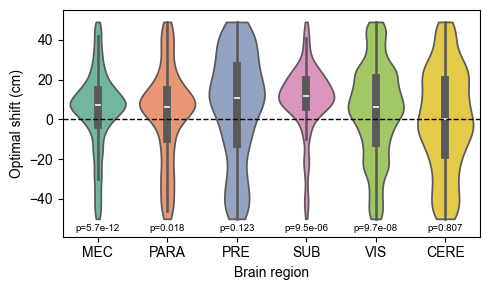

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# List of brain regions and their dataframes
regions = ['MEC', 'PARA', 'PRE', 'SUB', 'VIS', 'CERE']
dfs = [MEC_, PARA_, PRE_, SUB_, VIS_, CERE_]

# Collect data for plotting
data = []
for region, df in zip(regions, dfs):
    for val in df['optimal_travel_lag']:
        data.append({'region': region, 'optimal_travel_lag': val})

plot_df = pd.DataFrame(data)

# Compute p-values from linear mixed models
pvals_mixed = []
for region, df in zip(regions, dfs):
    df_region = df.dropna(subset=['optimal_travel_lag'])
    if len(df_region) < 5:
        pvals_mixed.append(np.nan)
        continue
    df_region['cluster_id'] = df_region['cluster_id'].astype(str)
    df_region['day'] = df_region['day'].astype(str)
    vc = {
        "day": "0 + C(day)",
        "cluster": "0 + C(cluster_id)"
    }
    try:
        model = smf.mixedlm(
            "optimal_travel_lag ~ 1",
            df_region,
            groups=df_region["mouse"],
            vc_formula=vc
        )
        result = model.fit()
        # Extract p-value for intercept
        pval = result.pvalues['Intercept']
        pvals_mixed.append(pval)
    except Exception as e:
        pvals_mixed.append(np.nan)

# Make violin plot
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(
    data=plot_df, 
    x='region', 
    y='optimal_travel_lag', 
    ax=ax, 
    palette='Set2',
    cut=0
)

# Annotate mixed model p-values at the bottom of each violin
# Annotate mixed model p-values at the bottom of each violin
for i, pval in enumerate(pvals_mixed):
    if np.isnan(pval):
        label = "n/a"
    elif pval < 0.001:
        label = f"p={pval:.1e}"
    else:
        label = f"p={pval:.3f}"
    ax.text(i, -57, label, ha='center', va='bottom', fontsize=7, color='black')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Optimal shift (cm)')
ax.set_xlabel('Brain region')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-59, 55)
fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_brain_region.pdf', bbox_inches='tight')
plt.show()

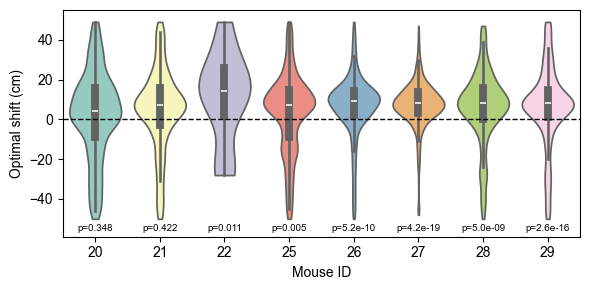

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Subset ENT cells for each mouse and collect data
data_mouse = []
for df in dfs:
    df_ent = df[df['brain_region'].str.contains('ENT', na=False)]
    for _, row in df_ent.iterrows():
        data_mouse.append({
            'mouse': row['mouse'],
            'optimal_travel_lag': row['optimal_travel_lag'],
            'cluster_id': row.get('cluster_id', None),
            'day': row.get('day', None)
        })

plot_df_mouse = pd.DataFrame(data_mouse)

# Make mouse ID integer then string for x label
plot_df_mouse['mouse'] = plot_df_mouse['mouse'].astype(int).astype(str)
mouse_ids = sorted(plot_df_mouse['mouse'].unique(), key=int)

# Compute p-values from linear mixed models for each mouse
pvals_mixed_mouse = []
for mouse in mouse_ids:
    df_mouse = plot_df_mouse[plot_df_mouse['mouse'] == mouse].dropna(subset=['optimal_travel_lag'])
    if len(df_mouse) < 5:
        pvals_mixed_mouse.append(np.nan)
        continue
    if 'cluster_id' in df_mouse.columns and 'day' in df_mouse.columns:
        df_mouse['cluster_id'] = df_mouse['cluster_id'].astype(str)
        df_mouse['day'] = df_mouse['day'].astype(str)
        vc = {
            "day": "0 + C(day)",
            "cluster": "0 + C(cluster_id)"
        }
    else:
        vc = {}
    try:
        model = smf.mixedlm(
            "optimal_travel_lag ~ 1",
            df_mouse,
            groups=df_mouse["mouse"],
            vc_formula=vc if vc else None
        )
        result = model.fit()
        pval = result.pvalues['Intercept']
        pvals_mixed_mouse.append(pval)
    except Exception as e:
        pvals_mixed_mouse.append(np.nan)

# Make violin plot grouped by mouse
fig, ax = plt.subplots(figsize=(6, 3))
sns.violinplot(
    data=plot_df_mouse, 
    x='mouse', 
    y='optimal_travel_lag', 
    ax=ax, 
    palette='Set3',
    cut=0
)

# Annotate mixed model p-values at the bottom of each violin
for i, pval in enumerate(pvals_mixed_mouse):
    if np.isnan(pval):
        label = "n/a"
    elif pval < 0.001:
        label = f"p={pval:.1e}"
    else:
        label = f"p={pval:.3f}"
    ax.text(i, -57, label, ha='center', va='bottom', fontsize=7, color='black')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Optimal shift (cm)')
ax.set_xlabel('Mouse ID')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-59, 55)
fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/optimal_lag_by_mouse_ENT.pdf', bbox_inches='tight')
plt.show()